# Figure 3 — Foundation validation: masked-band reconstruction

Three **held-out** ECDFS tiles (validation split, unseen in training), one representative band
each: Rubin r, Euclid VIS, Euclid NISP H. For each, the band is withheld and reconstructed from
the other nine (the pre-training objective). Columns: truth / model / residual on a diverging
scale set to the source peak — the residual is near-empty relative to the signal, conveying
faithful reconstruction. Per-panel: bright-pixel correlation r.

**Caching:** the heavy inference (model load + 790-tile dataset scan + forward passes, ~1–2 min)
is cached to `_fig3_recon_cache.pkl`. Re-running only re-reads the cache, so you can tweak the
**plot cell** and re-execute in seconds. To force a recompute (e.g. after changing `ROWS`, `FOV`,
or the checkpoint) the cache key auto-invalidates; or set `FORCE = True`.

Pure inference on `models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt`. Saves
`paper/figures/fig3_reconstruction.png`.

In [3]:
import sys, pickle, numpy as np, torch
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)

# --- config (changing any of these auto-invalidates the cache) ---
ROWS = [(218, 'rubin_r', 0.2), (786, 'euclid_VIS', 0.1), (479, 'euclid_H', 0.1)]  # (held-out idx, band, px-scale)
FOV  = 48.0  # arcsec central crop
CKPT = REPO / 'models' / 'checkpoints' / 'jaisp_v10_warmstart' / 'checkpoint_best.pt'

# --- cache: the heavy inference is saved to disk; flip FORCE=True to recompute ---
CACHE = REPO / 'paper_figures' / '_fig3_recon_cache.pkl'
FORCE = False
cache_key = {'rows': ROWS, 'fov': FOV, 'ckpt': str(CKPT)}

rows = None
if CACHE.exists() and not FORCE:
    with open(CACHE, 'rb') as f:
        blob = pickle.load(f)
    if blob.get('key') == cache_key:
        rows = blob['rows']
        print('loaded reconstruction from cache:', CACHE.name)

if rows is None:
    print('cache miss -> running inference (model load + 790-tile scan + forward passes)...')
    sys.path.insert(0, str(REPO / 'models'))
    from load_foundation import load_foundation
    from jaisp_dataset_v10 import JAISPDatasetV10
    dev = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    ckpt = torch.load(str(CKPT), map_location='cpu', weights_only=False)
    VAL_IDX = set(ckpt['val_indices'])
    model = load_foundation(str(CKPT), device=dev, freeze=True)
    ds = JAISPDatasetV10(rubin_dir=str(REPO/'data'/'rubin_tiles_all'),
                         euclid_dir=str(REPO/'data'/'euclid_tiles_all'),
                         load_euclid=True, augment=False)

    def cc(a, ps):
        h = int(round(FOV/ps/2)); c0, c1 = a.shape[0]//2, a.shape[1]//2
        return a[c0-h:c0+h, c1-h:c1+h]

    rows = []
    for idx, band, ps in ROWS:
        assert idx in VAL_IDX, f'tile {idx} not held out!'
        s = ds[idx]; pool = {}; pool.update(s['rubin']); pool.update(s.get('euclid', {}))
        ctx = [x for x in pool if x != band]
        ci = {x: pool[x]['image'].unsqueeze(0).to(dev) for x in ctx}
        cr = {x: pool[x]['rms'].unsqueeze(0).to(dev) for x in ctx}
        ti = pool[band]['image'].unsqueeze(0).to(dev); tr = pool[band]['rms'].unsqueeze(0).to(dev)
        with torch.no_grad():
            out = model(ci, cr, band, ti, tr)
        truth = out['target_norm'][0,0].cpu().numpy(); pred = out['pred'][0,0].cpu().numpy()
        info = out['info_weights'][0,0].cpu().numpy(); m = info >= np.nanpercentile(info, 90)
        r = float(np.corrcoef(truth[m], pred[m])[0,1])
        T, P = cc(truth, ps), cc(pred, ps)
        rows.append(dict(idx=idx, band=band, tile=ds.tiles[idx]['tile_id'],
                         truth=T, pred=P, resid=T - P, r=r))
        print(f'{band:11s} tile {idx}  r={r:.3f}')
    with open(CACHE, 'wb') as f:
        pickle.dump({'key': cache_key, 'rows': rows}, f)
    print('cached ->', CACHE.name)

print('rows ready:', [(d['band'], round(d['r'], 3)) for d in rows])

loaded reconstruction from cache: _fig3_recon_cache.pkl
rows ready: [('rubin_r', 0.998), ('euclid_VIS', 0.898), ('euclid_H', 0.958)]


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig3_reconstruction.png


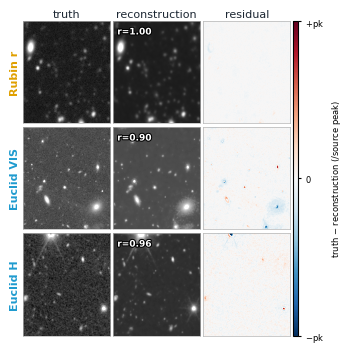

In [6]:
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'; INK = '#1c2733'
BANDLAB = {'rubin_r':('Rubin r', C_RUBIN), 'euclid_VIS':('Euclid VIS', C_EUCLID),
           'euclid_H':('Euclid H', C_EUCLID)}

# Single-column (AAS) geometry: build at ~column width so fonts render true-size.
fig = plt.figure(figsize=(3.5, 3.55))
gs = GridSpec(3, 4, figure=fig, width_ratios=[1, 1, 1, 0.05], wspace=0.04, hspace=0.04,
              left=0.115, right=0.90, top=0.90, bottom=0.015)
colhead = ['truth', 'reconstruction', 'residual']
im_res = None
for i, d in enumerate(rows):
    nrm = ImageNormalize(d['truth'], interval=PercentileInterval(99.5), stretch=AsinhStretch(0.1))
    V = float(np.nanpercentile(d['truth'], 99.5))   # bright scale; residual shown on +/- V
    name, col = BANDLAB[d['band']]
    for j, key in enumerate(['truth', 'pred', 'resid']):
        ax = fig.add_subplot(gs[i, j])
        if key == 'resid':
            im_res = ax.imshow(d['resid'], origin='lower', cmap='RdBu_r', vmin=-V, vmax=V, aspect='auto')
        else:
            ax.imshow(d[key], origin='lower', cmap='gray', norm=nrm, aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_edgecolor('0.7'); s.set_linewidth(0.5)
        if i == 0:
            ax.set_title(colhead[j], fontsize=8, color=INK, pad=3)
        if j == 0:
            ax.set_ylabel(name, fontsize=8, color=col, weight='bold', labelpad=2)
        if j == 1:
            ax.text(0.05, 0.94, f"r={d['r']:.2f}", transform=ax.transAxes, ha='left', va='top',
                    fontsize=6.5, color='white', weight='bold',
                    path_effects=[__import__('matplotlib.patheffects', fromlist=['withStroke']).withStroke(linewidth=1.5, foreground='black')])
# shared residual colorbar. The residual is signed (truth - model): red = model under-predicted,
# blue = over-predicted. Each row's residual is scaled to ITS OWN source peak, so the endpoints
# are labelled conceptually (-peak / 0 / +peak): a residual reaches full color only if an error
# is as large as the brightest source pixel. Near-white => faithful reconstruction.
cax = fig.add_subplot(gs[:, 3])
cb = fig.colorbar(im_res, cax=cax)
cb.set_ticks([-V, 0, V])
cb.set_ticklabels([r'$-$pk', '0', r'$+$pk'])
cb.set_label('truth $-$ reconstruction (/source peak)', fontsize=6)
cb.ax.tick_params(labelsize=6, length=2)

#fig.suptitle('Masked-band reconstruction, held-out tiles', fontsize=8.5, weight='bold', y=0.965)
out = FIGDIR / 'fig3_reconstruction.png'
fig.savefig(out, dpi=400, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()